# HR Analytics - Predict Employee Attrition
**Objective:** Understand the main causes of employee resignation and predict future attrition.

**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)
Download link: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [5]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [6]:
# Step 1b: Load the dataset
# Update this path if your CSV is stored elsewhere
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", df.shape)
df.head()


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Step 2: Understand the Data

In [8]:
# Basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
# Check for missing values
df.isnull().sum().sum()


np.int64(0)

In [10]:
# Target column distribution
df['Attrition'].value_counts()


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_588\3637253768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


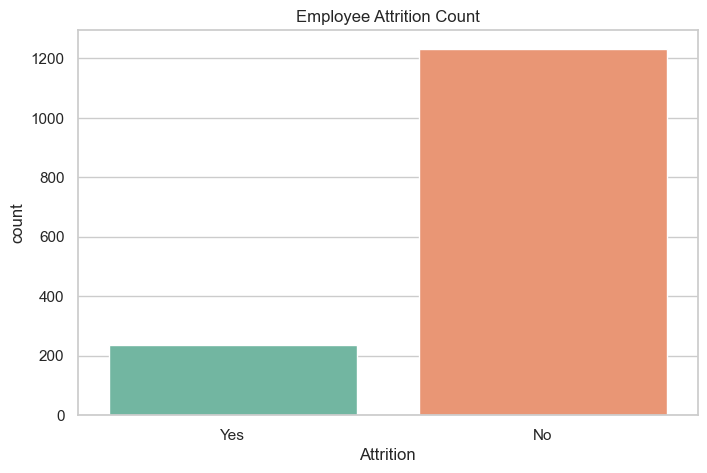

In [11]:
# Attrition rate (%)
attrition_rate = df['Attrition'].value_counts(normalize=True) * 100
print(attrition_rate)

sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title("Employee Attrition Count")
plt.savefig("chart_attrition_count.png", dpi=150, bbox_inches='tight')
plt.show()


## Step 3: Exploratory Data Analysis (EDA)

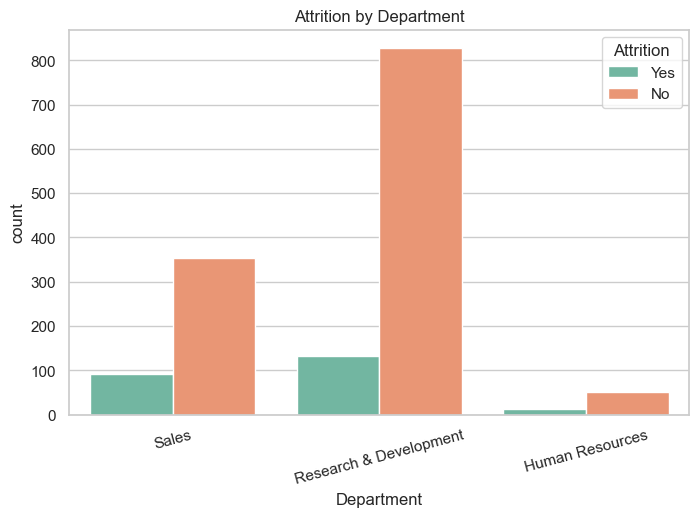

In [13]:
# Attrition by Department
plt.figure()
sns.countplot(x='Department', hue='Attrition', data=df, palette='Set2')
plt.title("Attrition by Department")
plt.xticks(rotation=15)
plt.savefig("chart_attrition_department.png", dpi=150, bbox_inches='tight')
plt.show()


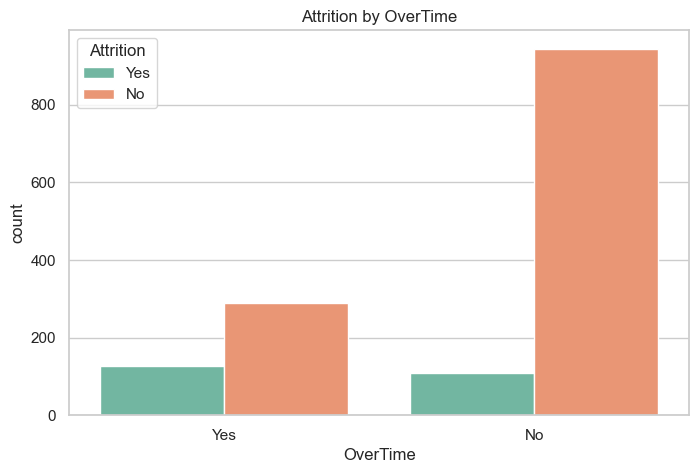

In [14]:
# Attrition by OverTime
plt.figure()
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set2')
plt.title("Attrition by OverTime")
plt.savefig("chart_attrition_overtime.png", dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_588\3979168130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')


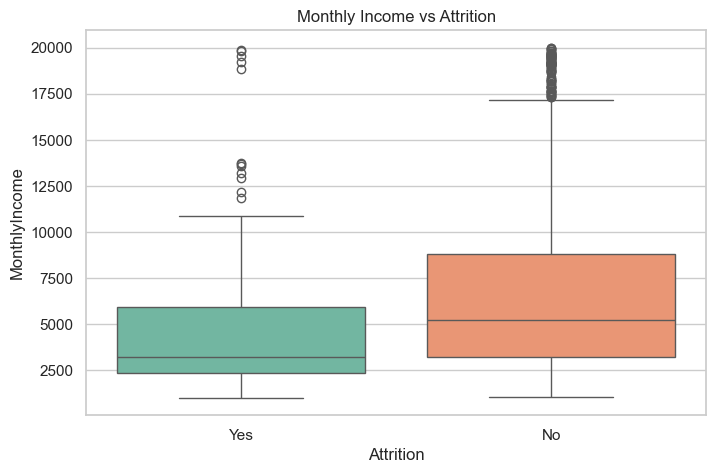

In [15]:
# Monthly Income vs Attrition
plt.figure()
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, palette='Set2')
plt.title("Monthly Income vs Attrition")
plt.savefig("chart_income_attrition.png", dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_588\4069324190.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, palette='Set2')


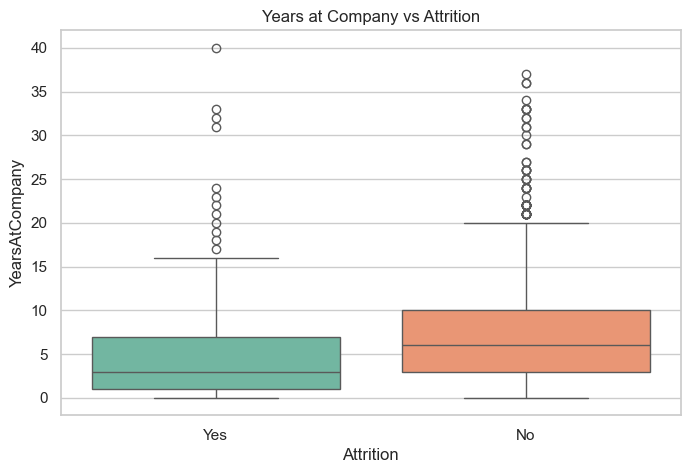

In [16]:
# Years at Company vs Attrition
plt.figure()
sns.boxplot(x='Attrition', y='YearsAtCompany', data=df, palette='Set2')
plt.title("Years at Company vs Attrition")
plt.savefig("chart_years_attrition.png", dpi=150, bbox_inches='tight')
plt.show()


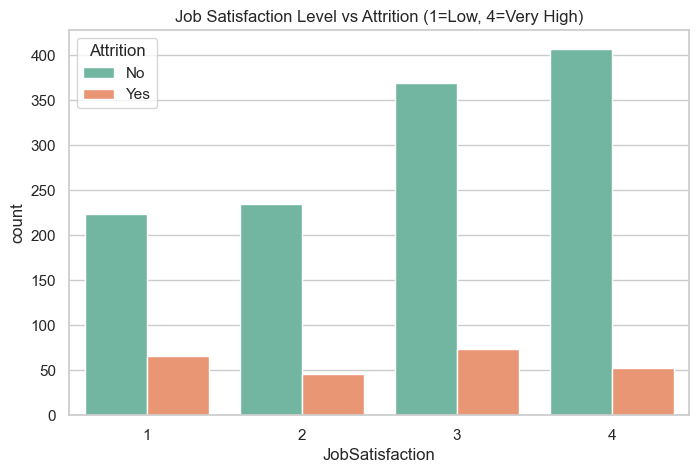

In [17]:
# Job Satisfaction vs Attrition
plt.figure()
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df, palette='Set2')
plt.title("Job Satisfaction Level vs Attrition (1=Low, 4=Very High)")
plt.savefig("chart_jobsatisfaction_attrition.png", dpi=150, bbox_inches='tight')
plt.show()


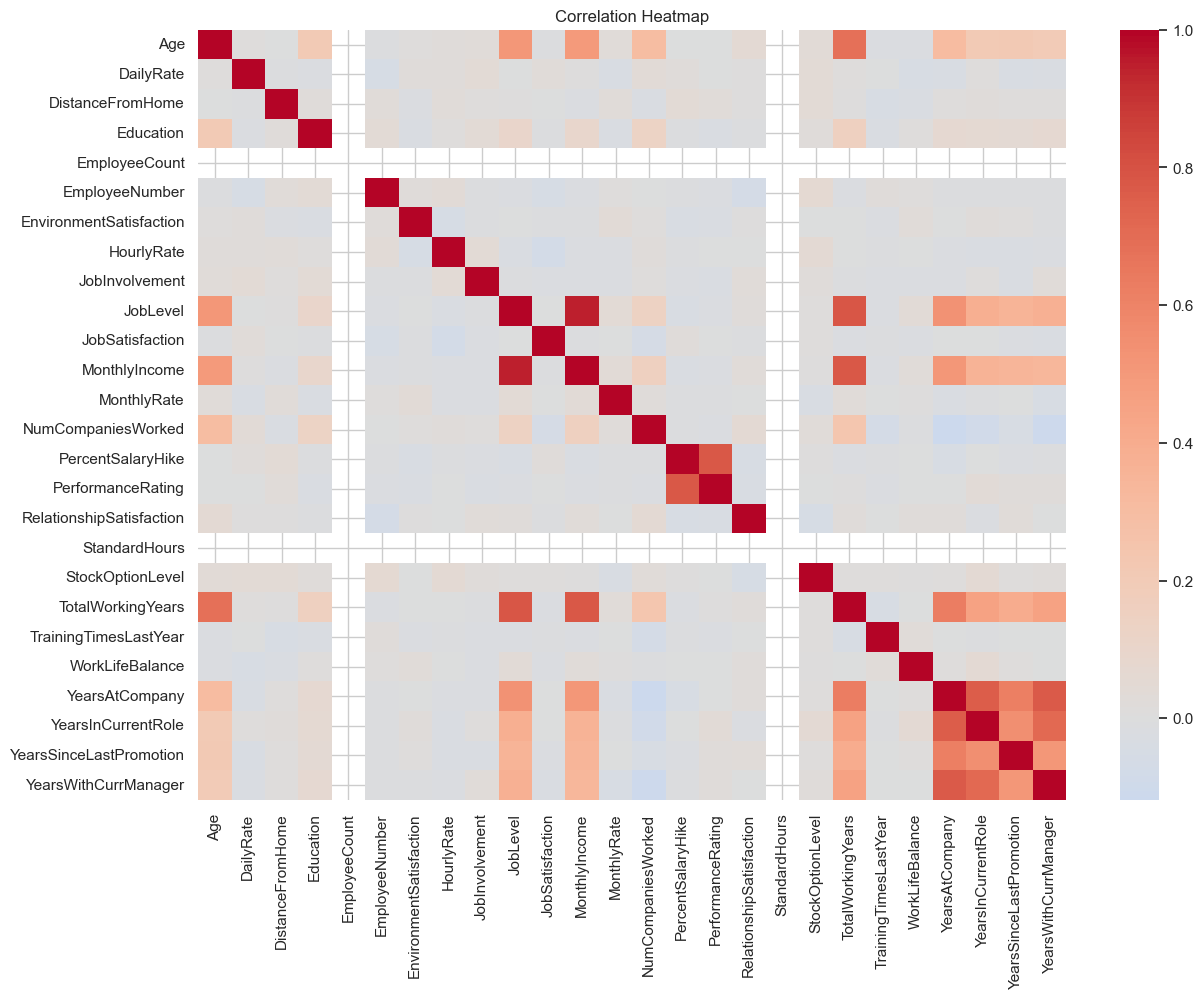

In [18]:
# Correlation heatmap (numeric features only)
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.savefig("chart_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


## Step 4: Prepare Data for Modeling

In [20]:
# Drop columns that are constant or not useful for prediction
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Encode target column
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Encode remaining categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

df_model.head()


Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


In [21]:
# Split features and target
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1176, 30)
Test shape: (294, 30)


## Step 5: Build the Model

In [23]:
# Logistic Regression (baseline, interpretable model)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [24]:
# Decision Tree (for comparison + easier SHAP explanation)
tree_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)


## Step 6: Evaluate the Models

In [26]:
def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall   :", round(recall_score(y_test, y_pred), 3))
    print("F1 Score :", round(f1_score(y_test, y_pred), 3))
    print()
    print(classification_report(y_test, y_pred))

evaluate_model("Logistic Regression", y_test, y_pred_log)
evaluate_model("Decision Tree", y_test, y_pred_tree)


--- Logistic Regression ---
Accuracy : 0.69
Precision: 0.307
Recall   : 0.745
F1 Score : 0.435

              precision    recall  f1-score   support

           0       0.93      0.68      0.79       247
           1       0.31      0.74      0.43        47

    accuracy                           0.69       294
   macro avg       0.62      0.71      0.61       294
weighted avg       0.83      0.69      0.73       294

--- Decision Tree ---
Accuracy : 0.765
Precision: 0.351
Recall   : 0.553
F1 Score : 0.43

              precision    recall  f1-score   support

           0       0.90      0.81      0.85       247
           1       0.35      0.55      0.43        47

    accuracy                           0.77       294
   macro avg       0.63      0.68      0.64       294
weighted avg       0.82      0.77      0.78       294



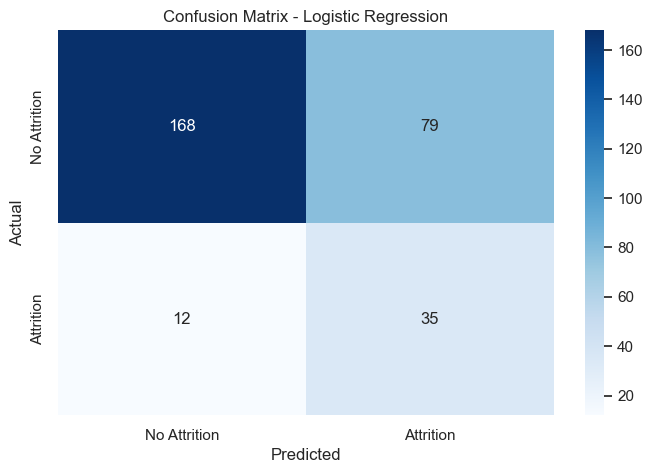

In [27]:
# Confusion Matrix - Logistic Regression
cm = confusion_matrix(y_test, y_pred_log)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title("Confusion Matrix - Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix_logreg.png", dpi=150, bbox_inches='tight')
plt.show()


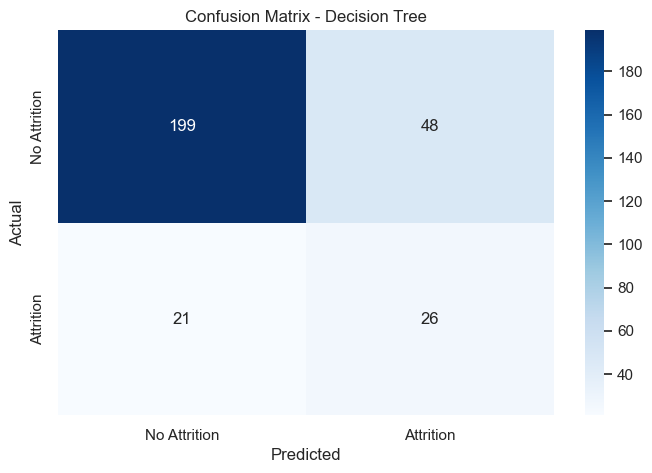

In [28]:
# Confusion Matrix - Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)
plt.figure()
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.title("Confusion Matrix - Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix_tree.png", dpi=150, bbox_inches='tight')
plt.show()


               feature  importance
23   TotalWorkingYears    0.199904
18            OverTime    0.168023
0                  Age    0.107178
22    StockOptionLevel    0.101745
17  NumCompaniesWorked    0.092586
15       MonthlyIncome    0.082141
3           Department    0.031590
25     WorkLifeBalance    0.030807
2            DailyRate    0.027248
19   PercentSalaryHike    0.027122


C:\Users\Admin\AppData\Local\Temp\ipykernel_588\560934864.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')


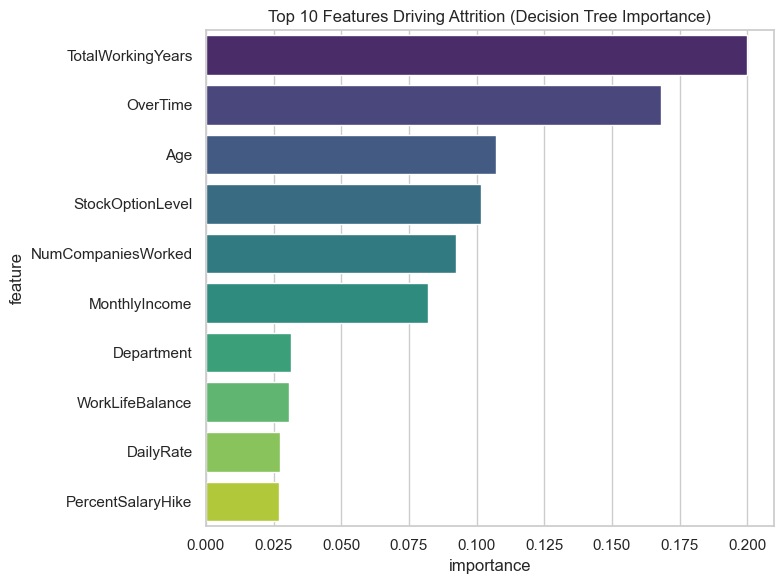

In [29]:
import pandas as pd

# Feature importance directly from the Decision Tree model
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': tree_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance_df.head(10))

plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=importance_df.head(10), palette='viridis')
plt.title("Top 10 Features Driving Attrition (Decision Tree Importance)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 8: Export Data for Power BI

In [31]:
# Export cleaned dataset (with original labels, not encoded) for Power BI
df_export = df.copy()
df_export.to_csv("hr_attrition_cleaned_for_powerbi.csv", index=False)

# Export feature importance for the Power BI insights page
importance_df.to_csv("feature_importance.csv", index=False)

print("Exported: hr_attrition_cleaned_for_powerbi.csv, feature_importance.csv")

Exported: hr_attrition_cleaned_for_powerbi.csv, feature_importance.csv
